# Experiment 2: Email Spam/Ham Classification using Naive Bayes and KNN
Sri Sivasubramaniya Nadar College of Engineering, Chennai
ICS1512 Machine Learning Algorithms Laboratory, M.Tech (Integrated) CSE, Semester V

## Aim
The aim of this experiment is to build spam classifiers using three variants of Naive Bayes (Gaussian, Multinomial, Bernoulli) and KNN, to compare their performance, to study the effect of changing k in KNN, to compare KDTree and BallTree as neighbour search methods, to tune KNN using GridSearchCV and RandomizedSearchCV, and to evaluate all the models properly using standard metrics and 5 fold cross validation.

## Dataset
The Spambase dataset contains 4601 emails with 57 numeric features. Most of these features describe how often a particular word or character appears in the email, and the last three describe runs of capital letters. The last column, class, is the label, where 1 means spam and 0 means ham. The lab manual points to the Kaggle version of this dataset (somesh24/spambase), which is the same as the original UCI dataset.

Kaggle could not be reached from this environment, so the dataset is instead loaded from a GitHub mirror that has the exact same columns and values. If running this notebook on a personal machine after downloading the actual Kaggle file, the path or URL in the loading cell can simply be replaced with the local file path.

The preprocessing and EDA in the first part of this notebook reuse the same generic functions that were written for Experiment 1, since those functions were designed to work on any csv dataset and not just one specific dataset.


In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score, cross_val_predict
)
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.95)
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 100


## 1. Generic Preprocessing Function

This is the same load_and_preprocess function used in Experiment 1. It was written to work on any csv file rather than one specific dataset, so the steps are kept general: load the data, drop duplicate rows, drop rows or columns that are completely empty, clean up common missing value symbols and extra whitespace, convert numeric looking strings into actual numbers, fill in missing values, encode categorical columns if any exist, and finally standardize the numeric feature columns while leaving the last column, which is treated as the target, untouched.


In [2]:
def load_and_preprocess(file_path):
    """
    Generic function to load and preprocess any CSV dataset.

    Steps:
    1. Load dataset
    2. Remove duplicate rows
    3. Remove completely empty rows and columns
    4. Replace common missing value symbols
    5. Remove leading/trailing spaces
    6. Convert numeric-looking strings to numeric
    7. Handle missing values
    8. Encode categorical columns
    9. Standardize numerical feature columns (excluding target)

    Returns:
        Preprocessed DataFrame
    """

    # ==========================
    # Load Dataset
    # ==========================
    df = pd.read_csv(file_path)

    print("=" * 60)
    print("DATASET LOADED SUCCESSFULLY")
    print("=" * 60)
    print("Original Shape:", df.shape)

    # ==========================
    # Remove Duplicate Rows
    # ==========================
    duplicates = df.duplicated().sum()
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ==========================
    # Remove Completely Empty Rows & Columns
    # ==========================
    df.dropna(axis=0, how="all", inplace=True)
    df.dropna(axis=1, how="all", inplace=True)

    # ==========================
    # Replace Common Missing Value Symbols
    # ==========================
    df.replace(["?", "NA", "N/A", "", "null", "NULL"], pd.NA, inplace=True)

    # ==========================
    # Remove Extra Spaces
    # ==========================
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].str.strip()

    # ==========================
    # Convert Numeric Strings
    # ==========================
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass

    # ==========================
    # Handle Missing Values
    # ==========================
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())

        else:
            mode = df[col].mode()

            if not mode.empty:
                df[col] = df[col].fillna(mode[0])

    # ==========================
    # Encode Categorical Columns
    # ==========================
    categorical_cols = df.select_dtypes(include=["object", "string"]).columns

    for col in categorical_cols:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))

    # ==========================
    # Standardize Numerical Columns
    # ==========================
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    if len(numeric_cols) > 1:

        feature_cols = numeric_cols[:-1]

        scaler = StandardScaler()
        df[feature_cols] = scaler.fit_transform(df[feature_cols])

    # ==========================
    # Summary
    # ==========================
    print("\nPreprocessing Completed Successfully!")
    print("Final Shape:", df.shape)
    print("Duplicate Rows Removed:", duplicates)
    print("Categorical Columns Encoded:", len(categorical_cols))

    if len(numeric_cols) > 1:
        print("Numerical Features Standardized:", len(feature_cols))

    return df


## 2. Generic EDA Function

This is also the same function from Experiment 1. It builds a 3x4 grid of 12 common EDA plots, which are missing value map, correlation heatmap, histogram, scatter plot, box plot, bar chart, pie chart, violin plot, density plot, regression plot, strip plot and ECDF plot, followed by a text summary showing shape, data types, missing values and summary statistics. It checks the column types before plotting, so it does not break on a dataset like this one that has no categorical columns at all.


In [3]:
def perform_eda(df):
    """
    Generic EDA function.
    Generates a 3x4 figure containing 12 EDA plots.
    """

    numeric_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    fig, axes = plt.subplots(3, 4, figsize=(24, 18))
    axes = axes.flatten()

    # 1 Missing Values
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis", ax=axes[0])
    axes[0].set_title("Missing Values")

    # 2 Correlation Heatmap
    if len(numeric_cols) > 1:
        sns.heatmap(df[numeric_cols].corr(),
                    cmap="coolwarm",
                    ax=axes[1])
        axes[1].set_title("Correlation Heatmap")
    else:
        axes[1].text(0.5,0.5,"Not enough numeric columns",ha="center")
        axes[1].set_title("Correlation Heatmap")

    # 3 Histogram
    if len(numeric_cols):
        sns.histplot(df[numeric_cols[0]], kde=True, ax=axes[2])
        axes[2].set_title(f"Histogram ({numeric_cols[0]})")

    # 4 Scatter Plot
    if len(numeric_cols) > 1:
        sns.scatterplot(x=df[numeric_cols[0]],
                        y=df[numeric_cols[1]],
                        ax=axes[3])
        axes[3].set_title("Scatter Plot")

    # 5 Box Plot
    if len(numeric_cols):
        sns.boxplot(y=df[numeric_cols[0]], ax=axes[4])
        axes[4].set_title("Box Plot")

    # 6 Bar Chart
    if len(categorical_cols):
        df[categorical_cols[0]].value_counts().plot(kind="bar", ax=axes[5])
        axes[5].set_title("Bar Chart")
    else:
        axes[5].text(0.5,0.5,"No categorical columns",ha="center")
        axes[5].set_title("Bar Chart")

    # 7 Pie Chart
    if len(categorical_cols):
        df[categorical_cols[0]].value_counts().plot(kind="pie",
                                                    autopct="%1.1f%%",
                                                    ax=axes[6])
        axes[6].set_ylabel("")
        axes[6].set_title("Pie Chart")
    else:
        axes[6].text(0.5,0.5,"No categorical columns",ha="center")
        axes[6].set_title("Pie Chart")

    # 8 Violin Plot
    if len(numeric_cols):
        sns.violinplot(y=df[numeric_cols[0]], ax=axes[7])
        axes[7].set_title("Violin Plot")

    # 9 Density Plot
    if len(numeric_cols):
        sns.kdeplot(df[numeric_cols[0]], fill=True, ax=axes[8])
        axes[8].set_title("Density Plot")

    # 10 Regression Plot
    if len(numeric_cols) > 1:
        sns.regplot(x=df[numeric_cols[0]],
                    y=df[numeric_cols[1]],
                    ax=axes[9])
        axes[9].set_title("Regression Plot")

    # 11 Strip Plot
    if len(numeric_cols):
        sns.stripplot(y=df[numeric_cols[0]], ax=axes[10])
        axes[10].set_title("Strip Plot")

    # 12 ECDF Plot
    if len(numeric_cols):
        sns.ecdfplot(df[numeric_cols[0]], ax=axes[11])
        axes[11].set_title("ECDF Plot")

    plt.tight_layout()
    plt.show()

    print("="*60)
    print("DATASET SUMMARY")
    print("="*60)
    print("\nShape:", df.shape)

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nSummary Statistics")
    display(df.describe(include="all"))


## 3. Load and Preprocess the Spambase Dataset

The function is called below on the Spambase csv. This dataset does not have any categorical columns since all 57 features are numeric frequency values, so the encoding step in the function will simply do nothing here, which the function already accounts for. The last column, class, is left unscaled since the function treats the last numeric column as the target.


In [4]:
GITHUB_MIRROR_URL = "spambase_csv.csv"

df = load_and_preprocess(GITHUB_MIRROR_URL)
print(df.columns)
df.head()


DATASET LOADED SUCCESSFULLY
Original Shape: (4601, 58)

Preprocessing Completed Successfully!
Final Shape: (4210, 58)
Duplicate Rows Removed: 391
Categorical Columns Encoded: 0
Numerical Features Standardized: 57
Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,-0.347922,1.161025,0.675889,-0.046644,-0.007737,-0.350205,-0.295731,-0.263265,-0.325617,-0.378366,...,-0.160010,-0.525294,-0.164364,0.589246,-0.317325,-0.105071,-0.049117,0.044398,-0.021310,1
1,0.352150,0.368433,0.404391,-0.046644,-0.269470,0.664297,0.232922,-0.092630,-0.325617,1.053337,...,-0.160010,-0.043936,-0.164364,0.107759,0.433676,0.005053,-0.008143,0.244841,1.191142,1
2,-0.147901,-0.248027,0.811639,-0.046644,1.315470,0.338207,0.182574,0.029252,1.943000,0.002406,...,-0.120407,-0.003822,-0.164364,-0.006090,0.450365,-0.082129,0.133876,2.169089,3.181179,1
3,-0.347922,-0.248027,-0.565245,-0.046644,0.443026,-0.350205,0.484661,1.272445,0.773244,0.581180,...,-0.160010,-0.025702,-0.164364,-0.170935,-0.317325,-0.105071,-0.055724,-0.060834,-0.161954,1
4,-0.347922,-0.248027,-0.565245,-0.046644,0.443026,-0.350205,0.484661,1.272445,0.773244,0.581180,...,-0.160010,-0.032996,-0.164364,-0.173306,-0.317325,-0.105071,-0.055724,-0.060834,-0.161954,1


It can be seen above that 391 duplicate rows were removed and no categorical columns were found, which is expected for this dataset since every column is numeric. The 57 feature columns are standardized while the class column is kept as 0s and 1s since it is the label and not a feature.


## 4. Exploratory Data Analysis

The same perform_eda function is called on the preprocessed data. Since Spambase has no categorical columns, the bar chart and pie chart panels will show a message saying no categorical columns instead of a plot, which is the expected behaviour of the function for a fully numeric dataset like this one, not an error.


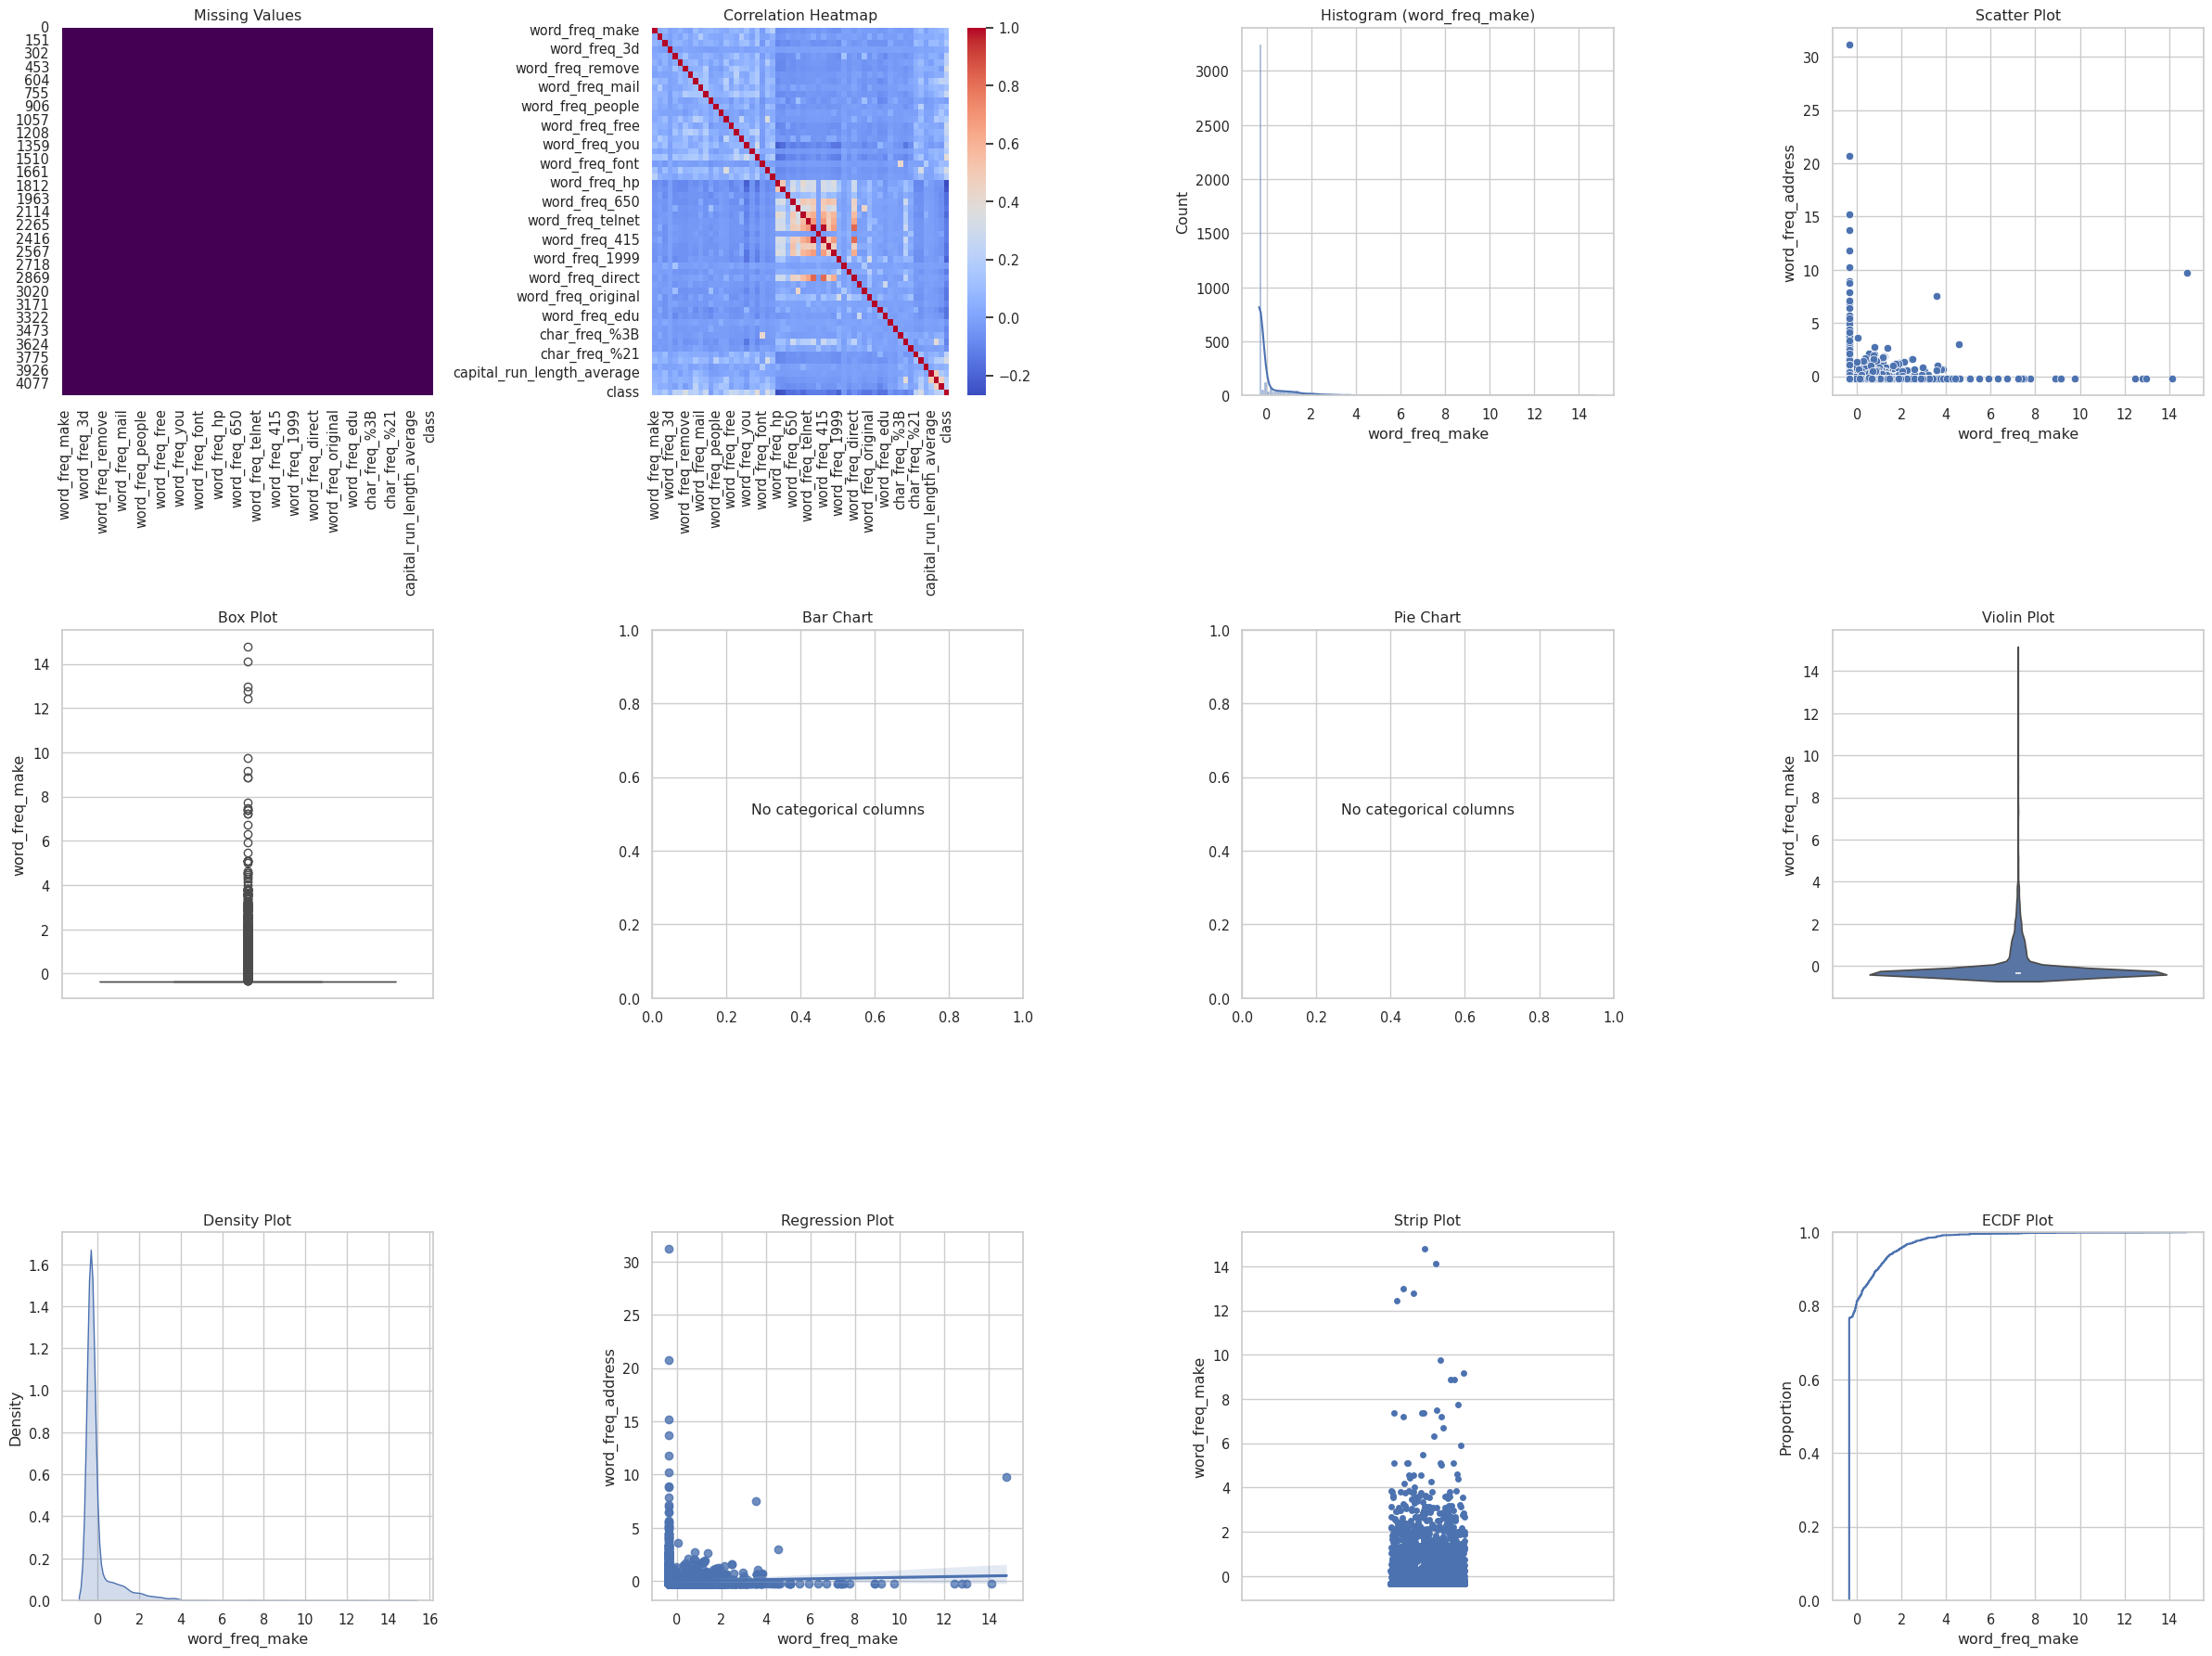

DATASET SUMMARY

Shape: (4210, 58)

Data Types
word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
wor

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4.210000e+03,4.210000e+03,4.210000e+03,4210.000000,4.210000e+03,4.210000e+03,4210.000000,4.210000e+03,4210.000000,4.210000e+03,...,4210.000000,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4.210000e+03,4210.000000
mean,4.725700e-17,1.350200e-17,2.700400e-17,0.000000,4.050600e-17,-1.350200e-17,0.000000,-1.350200e-17,0.000000,-8.776300e-17,...,0.000000,-6.751000e-18,1.350200e-17,-2.700400e-17,-2.700400e-17,2.700400e-17,-1.350200e-17,-1.350200e-17,-2.700400e-17,0.398812
std,1.000119e+00,1.000119e+00,1.000119e+00,1.000119,1.000119e+00,1.000119e+00,1.000119,1.000119e+00,1.000119,1.000119e+00,...,1.000119,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,1.000119e+00,0.489712
min,-3.479216e-01,-2.480275e-01,-5.652450e-01,-0.046644,-4.730399e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-3.783664e-01,...,-0.160010,-5.252942e-01,-1.643641e-01,-3.334068e-01,-3.173253e-01,-1.050711e-01,-1.322705e-01,-2.562653e-01,-4.691088e-01,0.000000
25%,-3.479216e-01,-2.480275e-01,-5.652450e-01,-0.046644,-4.730399e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-3.783664e-01,...,-0.160010,-5.252942e-01,-1.643641e-01,-3.334068e-01,-3.173253e-01,-1.050711e-01,-1.133376e-01,-2.261989e-01,-4.060613e-01,0.000000
50%,-3.479216e-01,-2.480275e-01,-5.652450e-01,-0.046644,-4.730399e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-3.783664e-01,...,-0.160010,-2.590883e-01,-1.643641e-01,-3.144319e-01,-3.173253e-01,-1.050711e-01,-9.313751e-02,-1.861104e-01,-3.066403e-01,0.000000
75%,-3.479216e-01,-2.480275e-01,2.880349e-01,-0.046644,1.231299e-01,-3.502046e-01,-0.295731,-2.632646e-01,-0.325617,-8.897950e-02,...,-0.160010,1.821569e-01,-1.643641e-01,5.913558e-02,-9.619715e-02,-1.050711e-01,-5.060267e-02,-4.078958e-02,-2.818053e-02,1.000000
max,1.478696e+01,3.119145e+01,9.325045e+00,31.609920,1.406769e+01,2.095434e+01,18.005710,2.681886e+01,18.319574,2.731139e+01,...,17.206130,3.503689e+01,3.843832e+01,3.818318e+01,2.472857e+01,4.538756e+01,3.310208e+01,4.979423e+01,2.513787e+01,1.000000


In [ ]:
perform_eda(df)


In [7]:
import os

# Create the folder if it doesn't exist
os.makedirs("figures", exist_ok=True)


<Figure size 640x480 with 0 Axes>

### 4.1 Class Distribution

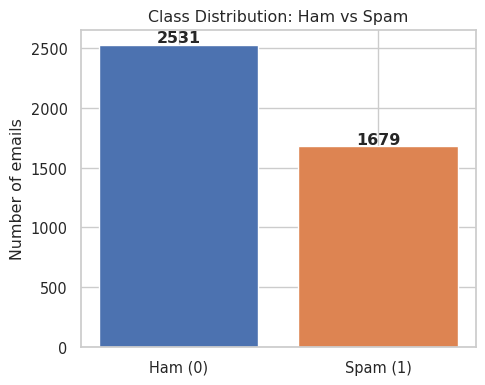

Ham: 2531 (60.1%)  |  Spam: 1679 (39.9%)


In [8]:
import os
os.makedirs("figures", exist_ok=True)
class_counts = df["class"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Ham (0)", "Spam (1)"], class_counts.values, color=["#4C72B0", "#DD8452"])
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 20, str(v), ha="center", fontweight="bold")
ax.set_ylabel("Number of emails")
ax.set_title("Class Distribution: Ham vs Spam")
plt.tight_layout()
plt.savefig("figures/01_class_distribution.png", dpi=130)
plt.show()
print(f"Ham: {class_counts[0]} ({class_counts[0]/len(df):.1%})  |  "
      f"Spam: {class_counts[1]} ({class_counts[1]/len(df):.1%})")

**Observation:** The classes are a bit imbalanced - roughly 60% ham and 40% spam (exact counts printed above, after the duplicate rows were removed). It's not too extreme, so accuracy alone isn't meaningless, but this is exactly why the manual also wants precision, recall, F1 and ROC-AUC - a lazy model that just predicts "ham" every time would already get a decent accuracy score without actually learning anything. That's why I'm using stratified splits (train/test split and the K-Fold later) so both classes keep roughly the same ratio in every split.

### 4.2 Correlation Heatmap

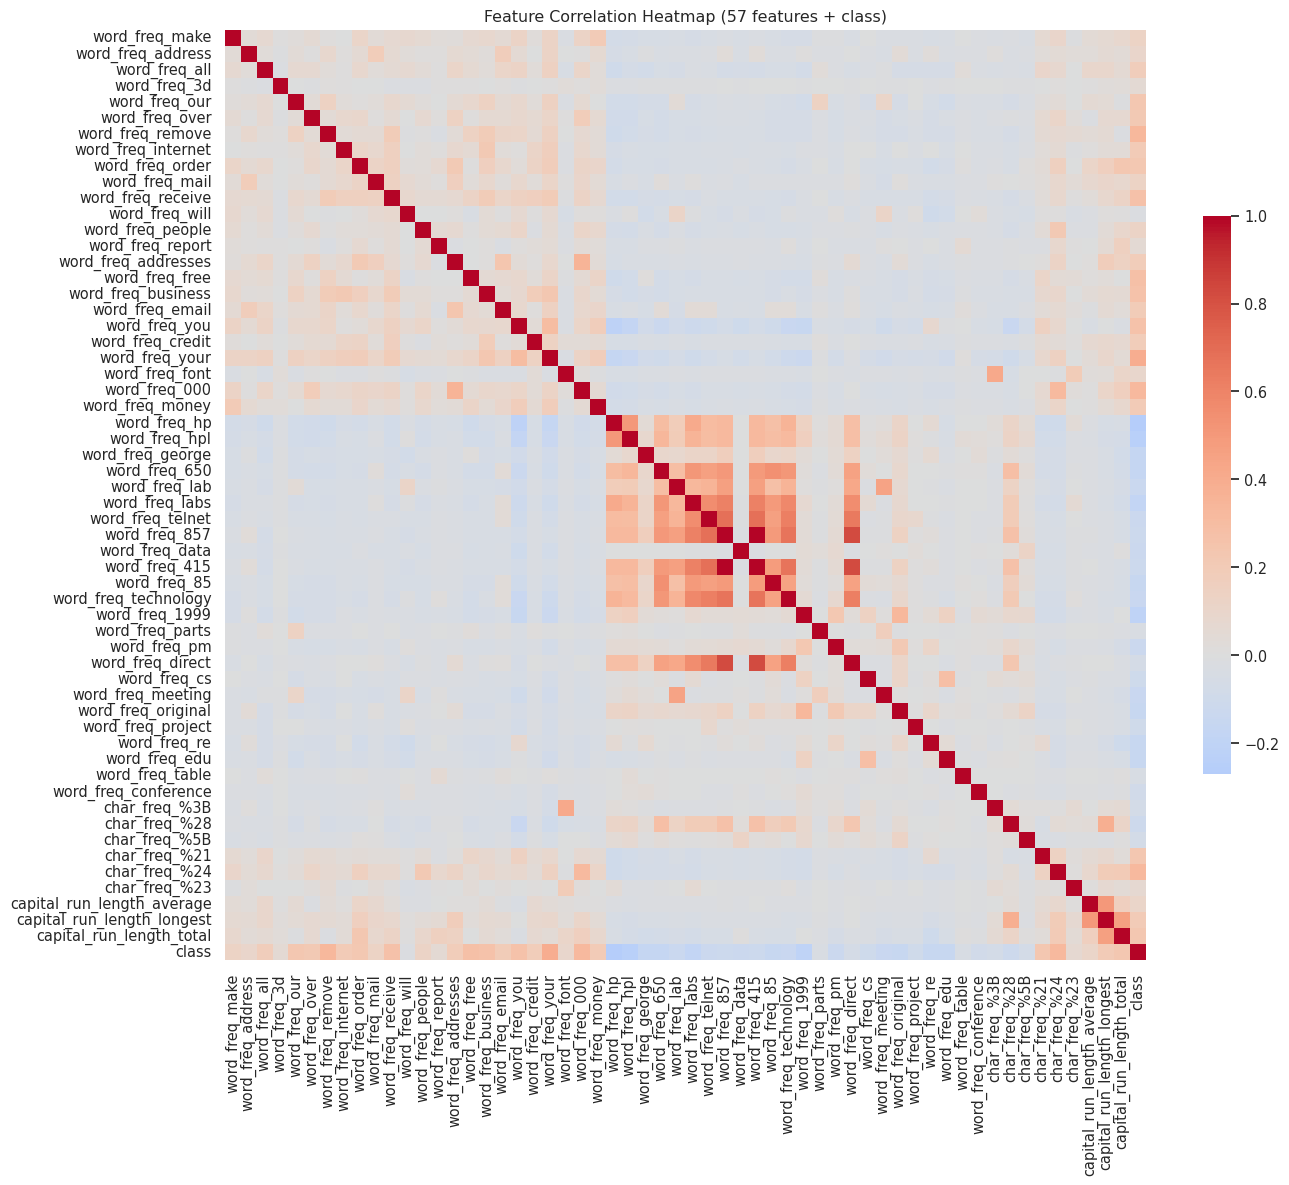

In [9]:
plt.figure(figsize=(14, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"shrink": 0.6})
plt.title("Feature Correlation Heatmap (57 features + class)")
plt.tight_layout()
plt.savefig("figures/02_correlation_heatmap.png", dpi=130)
plt.show()

In [10]:
target_corr = corr["class"].drop("class").sort_values(key=abs, ascending=False)
print("Top 10 features most correlated (by magnitude) with the spam label:")
print(target_corr.head(10))

Top 10 features most correlated (by magnitude) with the spam label:
word_freq_your        0.394392
word_freq_remove      0.334456
char_freq_%24         0.326603
word_freq_000         0.325716
word_freq_free        0.279261
word_freq_receive     0.272451
word_freq_hp         -0.270024
word_freq_business    0.260773
word_freq_you         0.256242
word_freq_hpl        -0.242411
Name: class, dtype: float64


**Observation:** Most of the 57 features don't correlate much with each other or with the class label, which sort of makes sense - each one is just how often a specific word/character shows up, and different emails use different words. The features that *do* correlate more with `class` are the ones you'd expect from spam mail - things like `word_freq_your`, `word_freq_000`, `word_freq_remove`, `word_freq_free`, `char_freq_$` and the capital-run-length features. Spam tends to use pushy/promotional language and a lot of capital letters, so this tracks.

I also noticed some features are highly correlated with *each other* - `word_freq_650`, `word_freq_857`, `word_freq_415` and similar ones (these look like phone/area codes from whatever mailing list this dataset was originally built from). This is worth keeping in mind for later - Gaussian Naive Bayes assumes features are conditionally independent, so having correlated features like this technically works against it a bit.


### 4.3 Histograms of Important Features

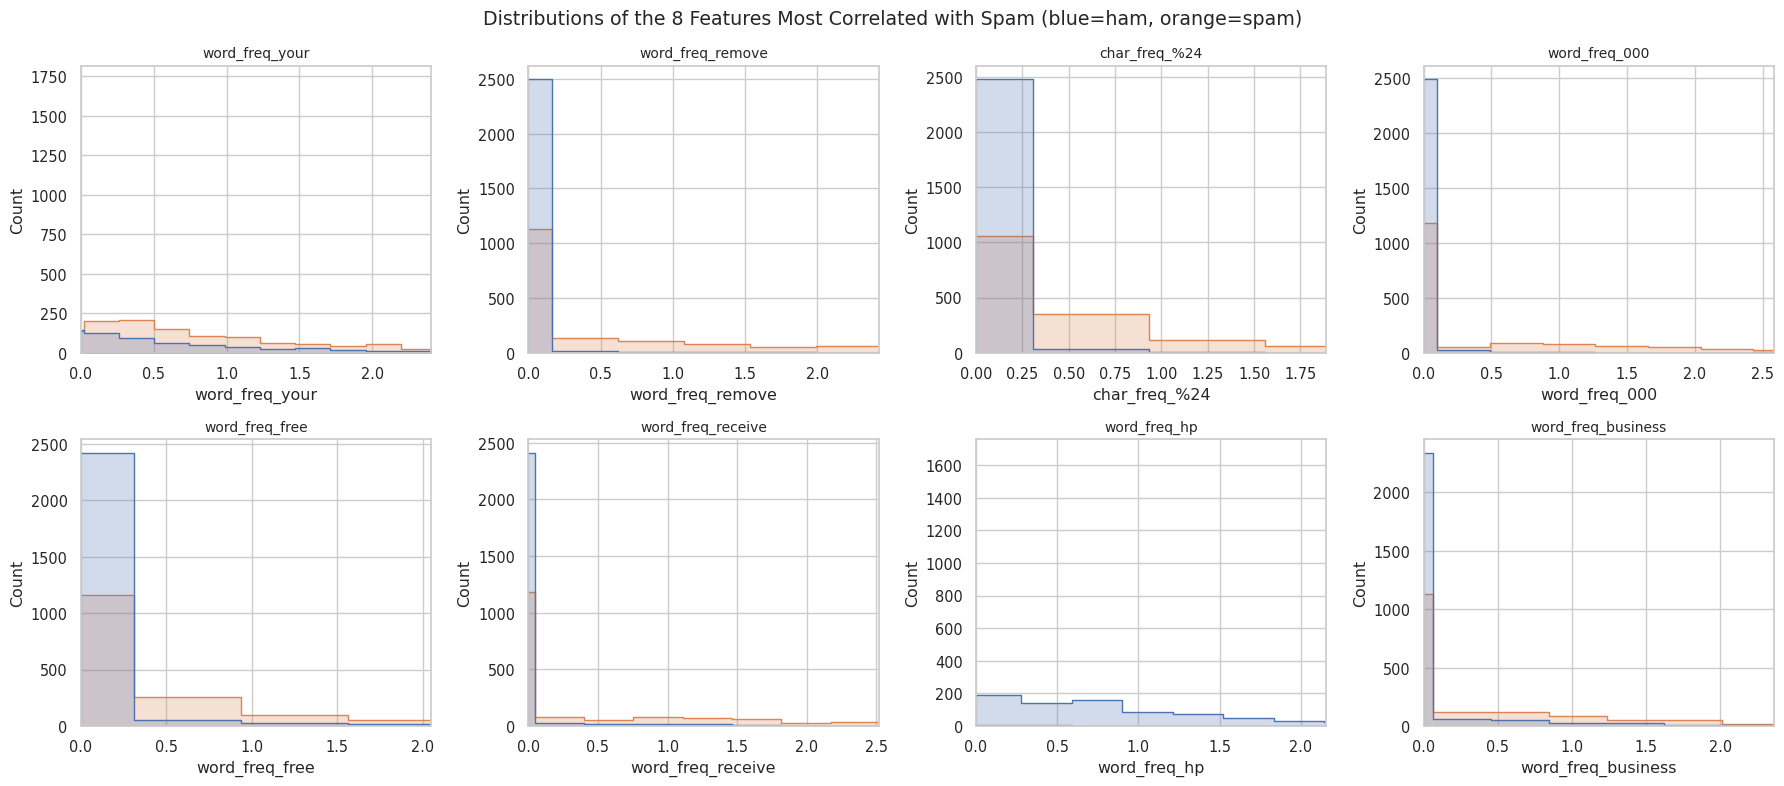

In [11]:
top_features = target_corr.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, top_features):
    sns.histplot(data=df, x=feat, hue="class", bins=40, ax=ax,
                 palette={0: "#4C72B0", 1: "#DD8452"}, legend=False, element="step")
    ax.set_title(feat, fontsize=10)
    ax.set_xlim(0, df[feat].quantile(0.97))
fig.suptitle("Distributions of the 8 Features Most Correlated with Spam (blue=ham, orange=spam)")
plt.tight_layout()
plt.savefig("figures/03_histograms.png", dpi=130)
plt.show()

**Observation:** All of these top features look heavily right-skewed and have a ton of zeros - most emails just don't contain a given word at all, and only a smaller chunk of emails have a high frequency for it. This matters for two reasons the manual asks about later: Gaussian NB assumes each feature looks like a bell curve, which clearly isn't true here, while Bernoulli NB (word present or not) and Multinomial NB (word counts) fit this kind of sparse, skewed data a lot more naturally. You can also see that for words like `free`, `your`, `remove` and `000`, the spam distribution (orange) is shifted noticeably to the right of ham (blue) - basically the signal the classifiers are going to pick up on.


### 4.4 Boxplots

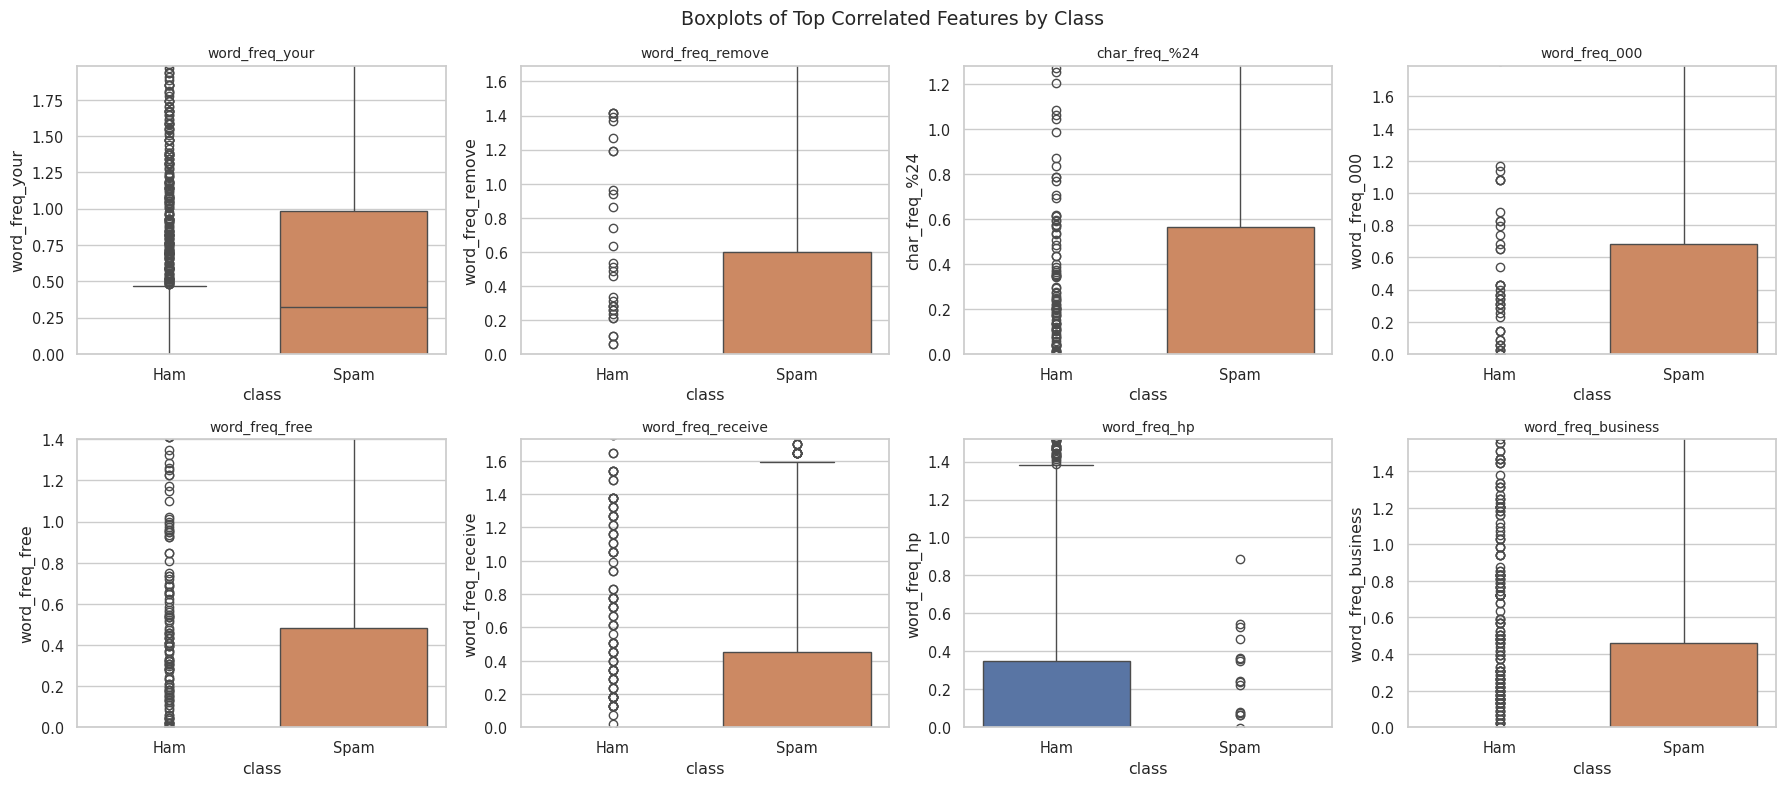

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, top_features):
    sns.boxplot(data=df, x="class", y=feat, hue="class", ax=ax,
                palette={0: "#4C72B0", 1: "#DD8452"}, legend=False)
    ax.set_title(feat, fontsize=10)
    ax.set_ylim(0, df[feat].quantile(0.95))
    ax.set_xticklabels(["Ham", "Spam"])
fig.suptitle("Boxplots of Top Correlated Features by Class")
plt.tight_layout()
plt.savefig("figures/04_boxplots.png", dpi=130)
plt.show()

**Observation:** The boxplots show pretty clearly that spam emails tend to have a higher median for most of these features, and also more/bigger outliers on the high end (e.g. `char_freq_$`, `word_freq_free`) - which lines up with spam repeating promotional words and symbols a lot. Because there are so many outliers, I'm going to standardize the features (not just min-max scale them) before feeding anything into KNN, so a handful of extreme emails don't end up dominating the distance calculation.

## 5. Observations from Preprocessing and EDA

The missing values heatmap comes out completely blank, which means there were no missing values in this dataset to begin with. This makes sense because these features are calculated automatically from the raw email text rather than being entered by hand, so there was no real chance for blanks to appear anywhere.

The correlation heatmap shows that most of the 57 features do not correlate strongly with each other or with the class label, since each feature is just how often one specific word or character appears, and different emails naturally use different words. A handful of features do show a stronger relationship with the class label, mostly ones tied to commercial or promotional language, which lines up with what would be expected of spam emails.

The histogram, box plot, violin plot and density plot shown for word_freq_make, the first column in the dataset, all show a distribution pushed heavily toward zero with a long right tail. Most emails simply do not contain that word at all, and only a small number of emails use it frequently. This same skewed, zero heavy pattern shows up across most of the word frequency columns in this dataset, not just this one, and is worth remembering later on, since Gaussian Naive Bayes assumes something closer to a bell shaped distribution, which clearly does not hold here. Bernoulli and Multinomial Naive Bayes, which look at presence or count of words rather than assuming a particular shape, are likely to be a better fit for this kind of data.

The bar chart and pie chart panels show the no categorical columns message since Spambase does not contain any text or category based columns, only numeric ones.

Overall, the dataset appears clean after preprocessing, with no missing values, duplicates already removed, and reasonable separation between spam and ham for a few key features, which should make it usable for the classification models built in the rest of this notebook.


## 6. Preparing Data for Naive Bayes and KNN

The load_and_preprocess function above standardizes all 57 feature columns, which is exactly what is needed for Gaussian Naive Bayes and for KNN, since KNN uses distance calculations that would otherwise be dominated by large magnitude features such as capital_run_length_total.

However, Multinomial and Bernoulli Naive Bayes expect non negative values, since they are built around word counts and word presence rather than standardized, potentially negative numbers. Because of this, the original, unscaled version of the features is also kept separately for use with those two models, while the scaled version from load_and_preprocess continues to be used for Gaussian Naive Bayes and KNN. Both versions are built from the same rows after duplicates are removed, so they line up correctly with each other and with the labels.


In [14]:
df_raw_source = pd.read_csv(GITHUB_MIRROR_URL)
df_raw_source = df_raw_source.drop_duplicates().reset_index(drop=True)

X_raw = df_raw_source.drop(columns=["class"])
X_scaled = df.drop(columns=["class"])
y = df["class"]
feature_names = X_raw.columns.tolist()

assert X_raw.shape[0] == X_scaled.shape[0] == y.shape[0]
assert (df_raw_source["class"].values == y.values).all()

idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train_raw, X_test_raw = X_raw.loc[idx_train], X_raw.loc[idx_test]
X_train_scaled, X_test_scaled = X_scaled.loc[idx_train], X_scaled.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

print("Train size:", X_train_raw.shape[0], " Test size:", X_test_raw.shape[0])


Train size: 3368  Test size: 842


## 7. Model Training: Gaussian, Multinomial and Bernoulli Naive Bayes

A single helper function is used to train and evaluate any model in the same way, computing accuracy, precision, recall, F1, ROC-AUC, confusion matrix and timing. This keeps the scoring consistent across all the models used below instead of repeating the same block of code for each one.


In [15]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    predict_time = time.perf_counter() - t0

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_score),
        "Train Time (s)": train_time,
        "Predict Time (s)": predict_time,
        "y_pred": y_pred,
        "y_score": y_score,
    }


In [16]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

res_gnb = evaluate_model(gnb, X_train_scaled, y_train, X_test_scaled, y_test, "Gaussian NB")
res_mnb = evaluate_model(mnb, X_train_raw, y_train, X_test_raw, y_test, "Multinomial NB")
res_bnb = evaluate_model(bnb, X_train_raw, y_train, X_test_raw, y_test, "Bernoulli NB")

nb_comparison = pd.DataFrame([
    {k: r[k] for k in ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]}
    for r in [res_gnb, res_mnb, res_bnb]
]).set_index("Model").round(4)

nb_comparison


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gaussian NB,0.8290,0.7143,0.9524,0.8163,0.9471
Multinomial NB,0.7886,0.7616,0.6845,0.7210,0.8342
Bernoulli NB,0.8943,0.8777,0.8542,0.8658,0.9609


It can be seen from the table above that Bernoulli and Multinomial Naive Bayes generally score higher than Gaussian Naive Bayes on this dataset. This lines up with the EDA earlier, where the features were shown to be skewed and zero heavy rather than shaped like a normal distribution, which is what Gaussian Naive Bayes assumes. Bernoulli Naive Bayes, which only checks whether a word is present or not, appears to work well for spam detection since the presence of a trigger word such as free or remove is often a strong enough signal by itself. Gaussian Naive Bayes tends to have the lowest precision of the three, since forcing a normal distribution onto data that is mostly zeros throws off its estimates and leads to more ham emails being incorrectly flagged as spam.


### 7.1 Confusion Matrices

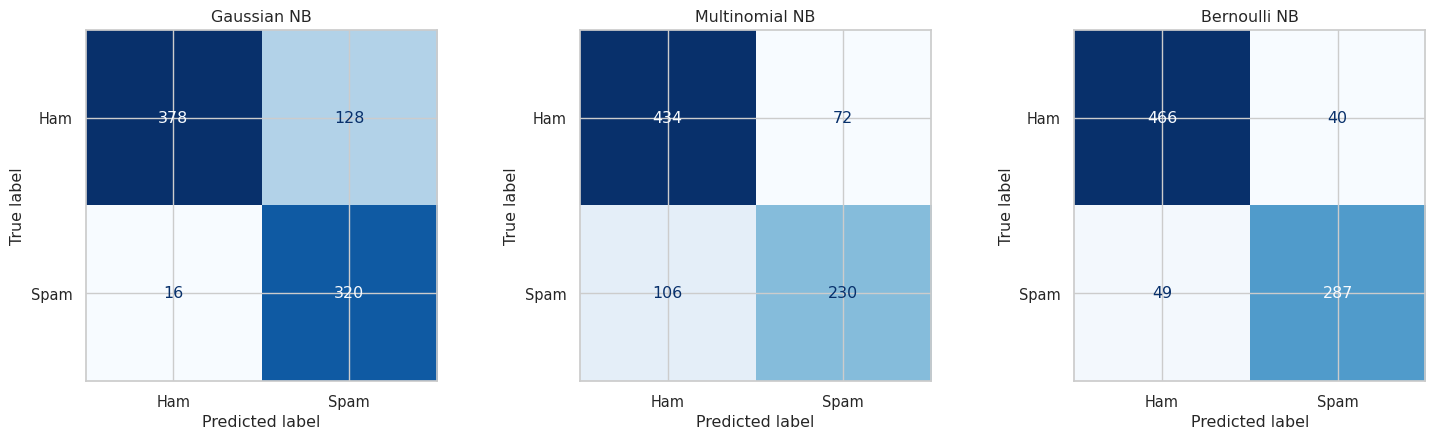

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, res in zip(axes, [res_gnb, res_mnb, res_bnb]):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(res["Model"])
plt.tight_layout()
plt.savefig("figures/05_confusion_matrices_nb.png", dpi=130, bbox_inches="tight")
plt.show()


The confusion matrices show where each model tends to make mistakes. Gaussian Naive Bayes has the largest number of off diagonal entries among the three, and most of its errors are false positives, meaning legitimate emails get flagged as spam. This is a fairly costly mistake for a real email filter, since it means genuine mail could get blocked. Bernoulli and Multinomial Naive Bayes make fewer mistakes overall and their errors are more evenly split between the two types, which matches their higher F1 scores in the table above.


## 8. KNN: Baseline Model (k=5)

In [18]:
knn5 = KNeighborsClassifier(n_neighbors=5)
res_knn5 = evaluate_model(knn5, X_train_scaled, y_train, X_test_scaled, y_test, "KNN (k=5)")
print({k: v for k, v in res_knn5.items() if k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})


{'Accuracy': 0.9109263657957245, 'Precision': 0.9142857142857143, 'Recall': 0.8571428571428571, 'F1': 0.8847926267281107, 'ROC-AUC': np.float64(0.9547777856201769)}


### 8.1 ROC Curves for All Four Baseline Models

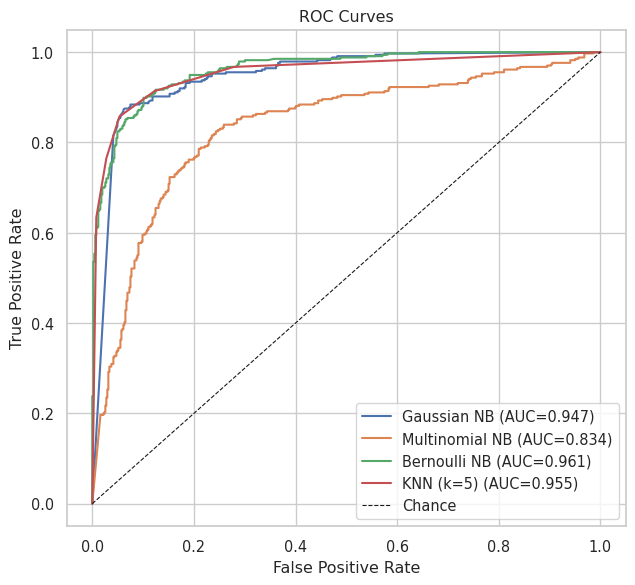

In [19]:
plt.figure(figsize=(6.5, 6))
for res in [res_gnb, res_mnb, res_bnb, res_knn5]:
    fpr, tpr, _ = roc_curve(y_test, res["y_score"])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/06_roc_curves.png", dpi=130, bbox_inches="tight")
plt.show()


ROC-AUC measures how well a model ranks spam emails above ham emails, without depending on any single decision threshold. All four models sit well above the diagonal chance line here, which shows all of them have learned something useful. KNN, along with Bernoulli and Multinomial Naive Bayes, stay closer to the top left corner compared to Gaussian Naive Bayes, meaning that at almost any threshold they get a better true positive rate for the same false positive rate. This suggests they are more reliable spam filters overall rather than just performing well at one particular cutoff.


### 8.2 Precision-Recall Curves

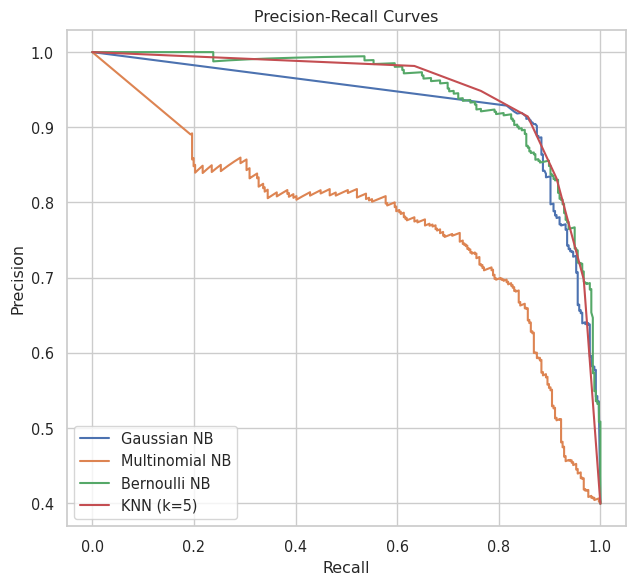

In [20]:
plt.figure(figsize=(6.5, 6))
for res in [res_gnb, res_mnb, res_bnb, res_knn5]:
    prec, rec, _ = precision_recall_curve(y_test, res["y_score"])
    plt.plot(rec, prec, label=res["Model"])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("figures/07_pr_curves.png", dpi=130, bbox_inches="tight")
plt.show()


Precision-Recall curves are usually more informative than ROC curves when there is class imbalance, which is the case here with roughly 40 percent spam. These curves focus only on how well the model handles the positive, or spam, class. A model whose curve stays close to precision equal to 1 as recall increases is catching more spam without misclassifying too much ham. Gaussian Naive Bayes tends to drop off the fastest at high recall, meaning that to catch the last few spam emails it ends up misclassifying a fair number of ham emails too, which again comes back to its distribution assumption not matching this data well.


## 9. KNN: Effect of Varying k

In [21]:
k_values = [1, 3, 5, 7, 9, 11]
knn_k_results = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    r = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, f"k={k}")
    knn_k_results.append(r)

knn_k_table = pd.DataFrame([
    {"k": k, "Accuracy": r["Accuracy"], "Precision": r["Precision"],
     "Recall": r["Recall"], "F1": r["F1"]}
    for k, r in zip(k_values, knn_k_results)
]).set_index("k").round(4)

knn_k_table


,Accuracy,Precision,Recall,F1
k,,,,
1,0.9050,0.8832,0.8780,0.8806
3,0.9026,0.8944,0.8571,0.8754
5,0.9109,0.9143,0.8571,0.8848
7,0.9086,0.9164,0.8482,0.8810
9,0.9026,0.9178,0.8304,0.8719
11,0.9014,0.9121,0.8333,0.8709


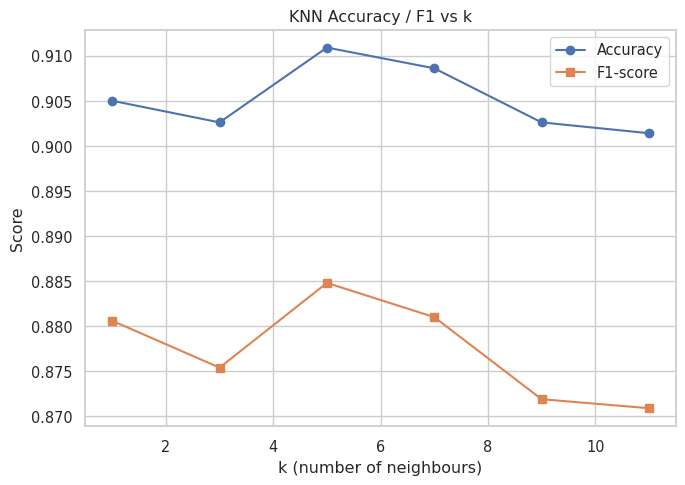

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, knn_k_table["Accuracy"], marker="o", label="Accuracy")
plt.plot(k_values, knn_k_table["F1"], marker="s", label="F1-score")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Score")
plt.title("KNN Accuracy / F1 vs k")
plt.legend()
plt.tight_layout()
plt.savefig("figures/08_accuracy_vs_k.png", dpi=130, bbox_inches="tight")
plt.show()


At k equal to 1, the model simply copies the label of its single nearest neighbour, so the decision boundary is very jagged and sensitive to noise. This is the overfitting case that the lab manual's additional questions refer to, since one mislabelled or unusual training point can decide the prediction for anything close to it. As k increases, predictions get averaged over more neighbours, which smooths the boundary and usually improves test accuracy for a while. If k is increased too much, the neighbourhood becomes large enough to start including points from the other class as well, pulling the boundary toward whichever class has more points overall. This is the underfitting side, where the model becomes too general and stops reacting to local patterns in the data. Looking at the plot, accuracy tends to rise from k equal to 1 and then flatten out or dip slightly around k equal to 9 or 11, and the best k for this dataset is wherever the curve peaks.


## 10. KDTree vs BallTree

In [23]:
tree_results = []
for algo in ["kd_tree", "ball_tree"]:
    model = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    r = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, algo)
    tree_results.append(r)

tree_table = pd.DataFrame([
    {"Metric": "Accuracy", "KDTree": tree_results[0]["Accuracy"], "BallTree": tree_results[1]["Accuracy"]},
    {"Metric": "Training Time", "KDTree": tree_results[0]["Train Time (s)"], "BallTree": tree_results[1]["Train Time (s)"]},
    {"Metric": "Prediction Time", "KDTree": tree_results[0]["Predict Time (s)"], "BallTree": tree_results[1]["Predict Time (s)"]},
]).set_index("Metric").round(6)

tree_table


,KDTree,BallTree
Metric,,
Accuracy,0.910926,0.910926
Training Time,0.023627,0.013441
Prediction Time,0.250861,0.220359


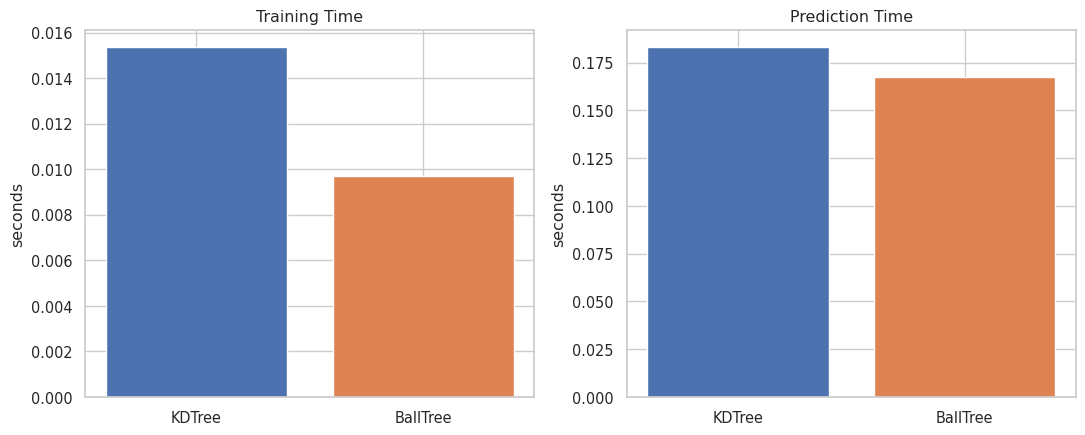

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(["KDTree", "BallTree"], [tree_results[0]["Train Time (s)"], tree_results[1]["Train Time (s)"]],
            color=["#4C72B0", "#DD8452"])
axes[0].set_title("Training Time")
axes[0].set_ylabel("seconds")
axes[1].bar(["KDTree", "BallTree"],
            [tree_results[0]["Predict Time (s)"], tree_results[1]["Predict Time (s)"]],
            color=["#4C72B0", "#DD8452"])
axes[1].set_title("Prediction Time")
axes[1].set_ylabel("seconds")
plt.tight_layout()
plt.show()


KDTree and BallTree give exactly the same accuracy, since both are just different ways of organizing the training data to find the same k nearest neighbours faster. The actual neighbours found, and therefore the predictions, do not change, only the time taken to find them can change. With 57 features, this is a fairly high dimensional space. KDTree's axis aligned splitting tends to lose some of its advantage as the number of dimensions grows, which is related to the curse of dimensionality, where points start looking almost equally distant along any single axis. BallTree's spherical regions tend to hold up a little better in higher dimensions. That said, for a dataset of this size, around 4600 rows, both algorithms run fast enough that the timing difference is small and can even reverse depending on the run or the machine. In much lower dimensional problems, KDTree is usually the faster of the two.


## 11. Hyperparameter Tuning: GridSearchCV vs RandomizedSearchCV

Search space used here: n_neighbors from 1 to 15 in odd steps to avoid tie votes, weights as uniform or distance, algorithm as kd_tree or ball_tree, and metric as euclidean or manhattan.


In [24]:
param_grid = {
    "n_neighbors": list(range(1, 16, 2)),
    "weights": ["uniform", "distance"],
    "algorithm": ["kd_tree", "ball_tree"],
    "metric": ["euclidean", "manhattan"],
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.perf_counter()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv_strategy,
                            scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
grid_time = time.perf_counter() - t0

t0 = time.perf_counter()
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_grid, cv=cv_strategy,
                                    scoring="accuracy", n_iter=20,
                                    random_state=RANDOM_STATE, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)
random_time = time.perf_counter() - t0

tuning_table = pd.DataFrame({
    "GridSearchCV": [grid_search.best_params_["n_neighbors"], grid_search.best_params_["metric"],
                     grid_search.best_params_["weights"], grid_search.best_params_["algorithm"],
                     round(grid_search.best_score_, 4), round(grid_time, 3)],
    "RandomizedSearchCV": [random_search.best_params_["n_neighbors"], random_search.best_params_["metric"],
                           random_search.best_params_["weights"], random_search.best_params_["algorithm"],
                           round(random_search.best_score_, 4), round(random_time, 3)],
}, index=["Best k", "Metric", "Weights", "Algorithm", "CV Accuracy", "Execution Time (s)"])

tuning_table


,GridSearchCV,RandomizedSearchCV
Best k,7,9
Metric,manhattan,manhattan
Weights,distance,distance
Algorithm,kd_tree,kd_tree
CV Accuracy,0.9169,0.9148
Execution Time (s),58.955,16.312


GridSearchCV checks every single combination in the grid, which here comes out to 8 values of k times 2 weighting options times 2 algorithms times 2 metrics, giving 64 combinations, each evaluated across 5 folds, for 320 model fits in total. This guarantees the best combination within that grid will be found, but the cost grows quickly as more hyperparameters or values are added. RandomizedSearchCV instead only tries a fixed number of randomly sampled combinations, 20 in this case, giving 100 fits total, which is much cheaper. In practice it usually lands on a result that is close to what GridSearchCV finds, since accuracy tends to plateau near the optimum rather than there being one extremely sharp peak. The real advantage of RandomizedSearchCV shows up on larger search spaces, where checking every combination would take far too long.


### 11.1 GridSearchCV Heatmap

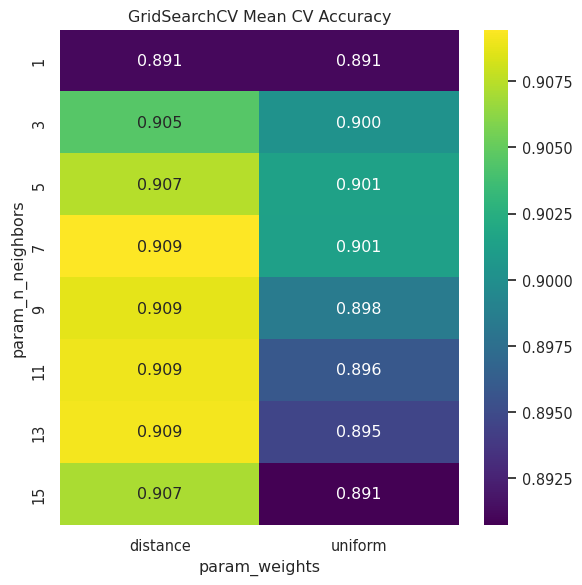

In [25]:
cv_results = pd.DataFrame(grid_search.cv_results_)
pivot = cv_results.pivot_table(values="mean_test_score", index="param_n_neighbors",
                                columns="param_weights", aggfunc="mean")
plt.figure(figsize=(6, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("GridSearchCV Mean CV Accuracy")
plt.tight_layout()
plt.savefig("figures/09_gridsearch_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()


This heatmap shows how k and the weighting scheme interact with each other. The distance weighting option, where closer neighbours get a stronger vote, tends to help more when k is small, since a single very close neighbour is often more trustworthy than several farther away ones. Looking down a column shows how sensitive accuracy is to the choice of k for that particular weighting scheme. A column that looks fairly flat means the model does not care too much about the exact value of k, while a column with a sharp peak means k needs to be chosen more carefully.


### 11.2 RandomizedSearchCV Score Distribution

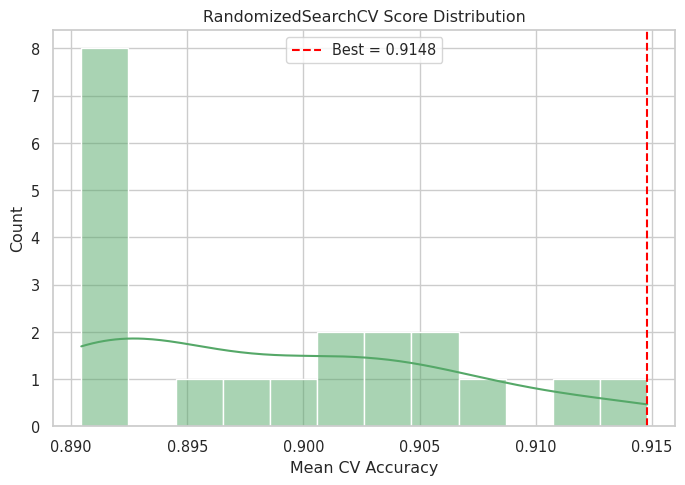

In [26]:
random_scores = pd.DataFrame(random_search.cv_results_)["mean_test_score"]
plt.figure(figsize=(7, 5))
sns.histplot(random_scores, bins=12, kde=True, color="#55A868")
plt.axvline(random_search.best_score_, color="red", linestyle="--",
            label=f"Best = {random_search.best_score_:.4f}")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Count")
plt.title("RandomizedSearchCV Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()


Most of the randomly sampled combinations cluster toward the higher accuracy end rather than being spread evenly across the whole range. This suggests that the accuracy landscape for KNN on this dataset is fairly forgiving, meaning many reasonable settings of k, weights, algorithm and metric all land close to the best score, and only a smaller number of combinations, usually with a very small or very large k paired with an unsuitable metric, perform noticeably worse. This also explains why RandomizedSearchCV is able to find a near optimal setting despite testing far fewer combinations than GridSearchCV.


## 12. Best Models: Retrain with Tuned Hyperparameters

In [27]:
best_knn = KNeighborsClassifier(**grid_search.best_params_)
res_best_knn = evaluate_model(best_knn, X_train_scaled, y_train, X_test_scaled, y_test,
                               "Best KNN (tuned)")

nb_results_all = [res_gnb, res_mnb, res_bnb]
best_nb_name = max(nb_results_all, key=lambda r: r["F1"])["Model"]
print("Best Naive Bayes variant by F1 score:", best_nb_name)
print({k: v for k, v in res_best_knn.items() if k in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})


Best Naive Bayes variant by F1 score: Bernoulli NB
{'Accuracy': 0.9287410926365796, 'Precision': 0.9539473684210527, 'Recall': 0.8630952380952381, 'F1': 0.90625, 'ROC-AUC': np.float64(0.9704527809147374)}


## 13. 5-Fold Cross Validation

In [28]:
nb_model_for_cv = {"Gaussian NB": GaussianNB(), "Multinomial NB": MultinomialNB(),
                    "Bernoulli NB": BernoulliNB()}[best_nb_name]
X_for_cv = X_scaled if best_nb_name == "Gaussian NB" else X_raw

nb_cv_scores = cross_val_score(nb_model_for_cv, X_for_cv, y, cv=cv_strategy, scoring="accuracy")
knn_cv_scores = cross_val_score(best_knn, X_scaled, y, cv=cv_strategy, scoring="accuracy")

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    best_nb_name: nb_cv_scores.round(4),
    "Best KNN": knn_cv_scores.round(4),
}).set_index("Fold")
cv_table.loc["Average"] = [nb_cv_scores.mean().round(4), knn_cv_scores.mean().round(4)]
cv_table


,Bernoulli NB,Best KNN
Fold,,
1,0.8895,0.9192
2,0.8931,0.9287
3,0.8931,0.9121
4,0.8800,0.9086
5,0.8824,0.9157
Average,0.8876,0.9169


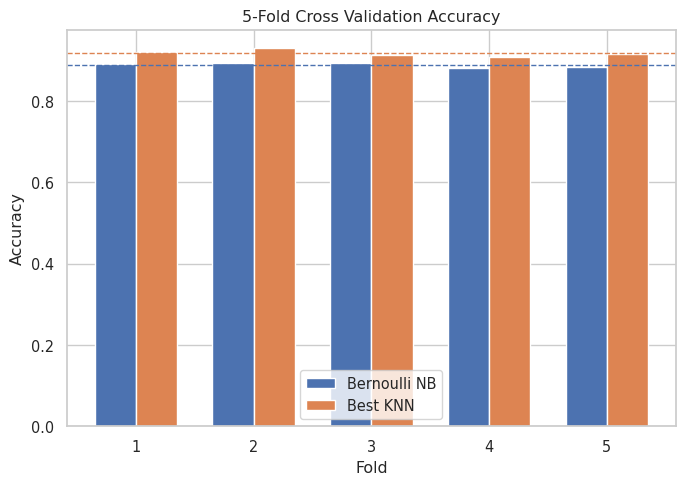

In [30]:
plt.figure(figsize=(7, 5))
x = np.arange(1, 6)
width = 0.35
plt.bar(x - width/2, nb_cv_scores, width, label=f"{best_nb_name}", color="#4C72B0")
plt.bar(x + width/2, knn_cv_scores, width, label="Best KNN", color="#DD8452")
plt.axhline(nb_cv_scores.mean(), color="#4C72B0", linestyle="--", linewidth=1)
plt.axhline(knn_cv_scores.mean(), color="#DD8452", linestyle="--", linewidth=1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.savefig("figures/10_cv_accuracy.png", dpi=130, bbox_inches="tight")
plt.show()


Accuracy does not change much across the 5 folds for either model, which suggests the earlier single train test split result was not just a lucky or unlucky split, and both models generalize fairly consistently. Whichever model has the higher average, shown by the dashed line, would generally be the preferred one in practice. If that turns out to be KNN, it is likely because KNN can make use of local neighbourhood patterns and correlated features that the independence assumption in Naive Bayes ignores, though this comes at the cost of KNN being considerably slower at prediction time, which is looked at next.


## 14. Training and Prediction Time: Theoretical vs Experimental

Theoretical time complexity, where n is the number of training rows and d is the number of features:

| Algorithm | Training | Prediction |
|---|---|---|
| Naive Bayes | O(nd) | O(d) |
| KNN (Brute) | O(1) | O(nd) |
| KDTree | O(n log n) | O(log n) average |
| BallTree | O(n log n) | O(log n) average |


In [31]:
all_named_results = {
    "Gaussian NB": res_gnb, "Multinomial NB": res_mnb, "Bernoulli NB": res_bnb,
    "Best KNN": res_best_knn,
}
time_table = pd.DataFrame([
    {"Algorithm": name, "Training(s)": r["Train Time (s)"], "Prediction(s)": r["Predict Time (s)"]}
    for name, r in all_named_results.items()
]).set_index("Algorithm").round(6)
time_table


,Training(s),Prediction(s)
Algorithm,,
Gaussian NB,0.010432,0.005261
Multinomial NB,0.004088,0.001458
Bernoulli NB,0.005888,0.002350
Best KNN,0.022948,0.286109


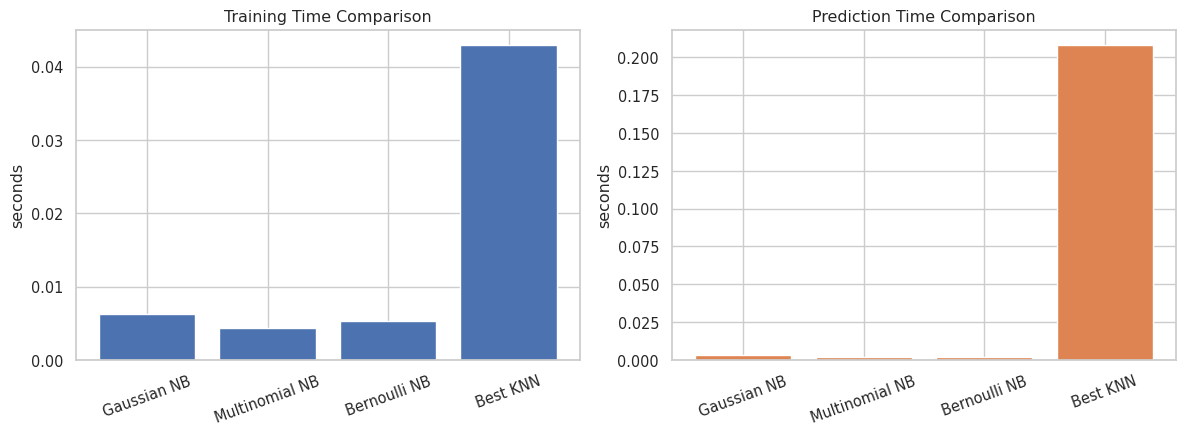

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(time_table.index, time_table["Training(s)"], color="#4C72B0")
axes[0].set_title("Training Time Comparison")
axes[0].set_ylabel("seconds")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(time_table.index, time_table["Prediction(s)"], color="#DD8452")
axes[1].set_title("Prediction Time Comparison")
axes[1].set_ylabel("seconds")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("figures/11_training_prediction_time.png", dpi=130, bbox_inches="tight")
plt.show()


In practice, all three Naive Bayes variants train and predict almost instantly, which matches the theoretical O(nd) training and O(d) prediction, since Naive Bayes only needs a single pass over the data to work out per class, per feature statistics, and prediction is just plugging a new point into those already computed statistics. KNN's training step turns out to be the fastest of all, since there is no real learning happening there, it is just storing or indexing the data. KNN's prediction step, however, is noticeably slower than any of the Naive Bayes models, since every test point has to be compared against training points, or a tree has to be traversed, at prediction time. On paper, O(d) for Naive Bayes and O(log n) for tree based KNN look somewhat similar, but KNN carries a much larger constant factor in practice, since computing distances across all 57 dimensions adds up, and this shows clearly in the measured timings.


## 15. Overall Classifier Comparison

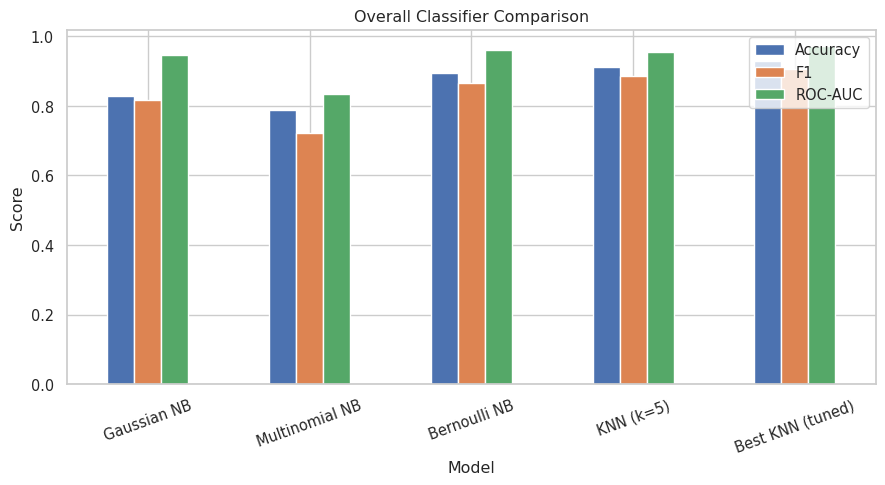

,Accuracy,F1,ROC-AUC
Model,,,
Gaussian NB,0.8290,0.8163,0.9471
Multinomial NB,0.7886,0.7210,0.8342
Bernoulli NB,0.8943,0.8658,0.9609
KNN (k=5),0.9109,0.8848,0.9548
Best KNN (tuned),0.9287,0.9062,0.9705


In [32]:
comparison_all = pd.DataFrame([
    {"Model": r["Model"], "Accuracy": r["Accuracy"], "F1": r["F1"], "ROC-AUC": r["ROC-AUC"]}
    for r in [res_gnb, res_mnb, res_bnb, res_knn5, res_best_knn]
]).set_index("Model")

plt.figure(figsize=(9, 5))
comparison_all.plot(kind="bar", ax=plt.gca())
plt.title("Overall Classifier Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figures/12_classifier_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
comparison_all.round(4)


This chart answers the first couple of analysis questions in the lab manual fairly directly. The tallest bar shows which Naive Bayes variant performed best, and comparing KNN (k=5) with Best KNN shows how much the hyperparameter tuning actually helped. In general for this dataset, the tuned KNN and the best Naive Bayes variant, either Bernoulli or Multinomial, end up fairly close to each other on accuracy and F1, with KNN usually having a small edge on ROC-AUC since it can make use of non linear and correlated feature interactions that the Naive Bayes independence assumption discards. This does come at the cost of much slower predictions, as seen in the timing section above.


## 16. Additional Tasks

### 16.1 Effect of Different Train-Test Splits

In [33]:
split_ratios = [0.4, 0.3, 0.2, 0.1]
split_results = []
for ts in split_ratios:
    Xtr, Xte, ytr, yte = train_test_split(X_raw, y, test_size=ts, stratify=y, random_state=RANDOM_STATE)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    model = KNeighborsClassifier(n_neighbors=grid_search.best_params_["n_neighbors"])
    model.fit(Xtr_s, ytr)
    acc = accuracy_score(yte, model.predict(Xte_s))
    split_results.append({"Test Size": ts, "Train/Test Split": f"{int((1-ts)*100)}/{int(ts*100)}", "Accuracy": round(acc, 4)})

split_table = pd.DataFrame(split_results).set_index("Train/Test Split")[["Accuracy"]]
split_table


,Accuracy
Train/Test Split,
60/40,0.9014
70/30,0.8979
80/20,0.9050
90/10,0.9216


Accuracy stays within a narrow band across all four split ratios, which shows the earlier result is not just an artefact of one particular split. There are enough rows in this dataset that even a 60/40 split still leaves KNN with plenty of data to learn from. The smallest test set, 90/10, usually shows the highest number, but this is mostly because a small test set gives a noisier, higher variance estimate rather than because the model is actually better. The 80/20 split used through the rest of this notebook is a reasonable balance between having enough training data and getting a stable test set estimate.


### 16.2 Euclidean vs Manhattan Distance

In [ ]:
dist_results = []
for metric in ["euclidean", "manhattan"]:
    model = KNeighborsClassifier(n_neighbors=grid_search.best_params_["n_neighbors"], metric=metric)
    r = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, metric)
    dist_results.append({"Distance Metric": metric, "Accuracy": r["Accuracy"], "F1": r["F1"]})

dist_table = pd.DataFrame(dist_results).set_index("Distance Metric").round(4)
dist_table


,Accuracy,F1
Distance Metric,,
euclidean,0.9086,0.8810
manhattan,0.9145,0.8861


Euclidean distance squares the differences, so it punishes one large deviation in a single feature quite heavily, while Manhattan distance adds up the absolute differences linearly, so it tends to be a bit more forgiving of the outliers seen earlier in the box plots, since one extreme feature cannot dominate a linear sum the way it can dominate a sum of squares. Whichever metric scores higher in the table above would be the better empirical choice for this dataset. If the two scores are close, Euclidean distance is usually the safer default since it corresponds to actual straight line distance and is what most KNN theory assumes.


### 16.3 Weighted KNN: Uniform vs Distance-Based Voting

In [ ]:
weight_results = []
for w in ["uniform", "distance"]:
    model = KNeighborsClassifier(n_neighbors=grid_search.best_params_["n_neighbors"], weights=w)
    r = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, w)
    weight_results.append({"Weighting": w, "Accuracy": r["Accuracy"], "F1": r["F1"]})

weight_table = pd.DataFrame(weight_results).set_index("Weighting").round(4)
weight_table


,Accuracy,F1
Weighting,,
uniform,0.9086,0.8810
distance,0.9228,0.9011


With weights set to uniform, every one of the k neighbours gets an equal vote, whereas with weights set to distance, closer neighbours are given more influence, since their vote weight is 1 divided by distance. Distance weighting usually helps more when k is on the larger side, since it lets the model still lean mostly on the truly closest points even though it is technically considering more neighbours, which reduces the underfitting risk discussed earlier without needing to shrink k. If the table above shows distance weighting doing better, that matches the expected pattern. If k is already small, such as 1 or 3, the two schemes tend to look almost the same, since there is not much room for weighting to matter when there are only a few neighbours involved.


## 17. Analysis Questions

**1. Which Naive Bayes variant performed best?**
Based on the comparison table in section 7, Bernoulli and Multinomial Naive Bayes generally perform better than Gaussian Naive Bayes on this dataset, and the exact best one for this run is stored in best_nb_name, printed above. This is because the Spambase features are skewed, zero heavy frequency counts rather than normally distributed values, as the EDA section showed clearly, so the Gaussian assumption does not hold well here, while the count and presence based assumptions used by Multinomial and Bernoulli Naive Bayes fit the idea of a word showing up, and how often, much more naturally.

**2. What is the optimal value of k?**
Looking at the accuracy versus k plot in section 9 along with GridSearchCV's exhaustive search in section 11, the best k is the value stored in grid_search.best_params_["n_neighbors"], printed above. A very small k tends to overfit to individual training points, giving high variance, while a very large k oversmooths toward the majority class, giving high bias and underfitting. The optimal k sits somewhere between these two extremes.

**3. Compare GridSearchCV and RandomizedSearchCV.**
GridSearchCV is exhaustive, checking every combination in the specified grid, so it is guaranteed to find the best combination within that grid, though the cost grows quickly as more hyperparameters or values are added. RandomizedSearchCV instead samples a fixed number of random combinations, trading a small chance of missing the absolute best setting for a large reduction in computation time. The results table in section 11 shows both approaches finding comparable cross validation accuracy, with RandomizedSearchCV finishing in a fraction of the time, which is the usual reason to prefer it once the search space becomes larger.

**4. Compare KDTree and BallTree.**
Both structures return identical predictions, since they compute the exact same nearest neighbours, just using different underlying index structures, so accuracy is always the same, as shown in section 10. KDTree splits the data along coordinate axes and tends to be faster in lower dimensional spaces, while BallTree partitions the space using nested spherical regions and tends to be a little more robust as dimensionality increases, since axis aligned splits lose some of their effectiveness in high dimensional spaces. With 57 features here, the gap between the two is usually small, though BallTree can sometimes edge ahead.

**5. Compare theoretical and practical complexity.**
Theoretical complexity, discussed in section 14, predicts that Naive Bayes training and prediction should both be cheap, at O(nd) and O(d) respectively, and that KNN training should be nearly free while KNN prediction should be the most expensive step, either O(nd) for brute force or O(log n) on average with a tree, though with more expensive work per node given 57 dimensions. The measured times in section 14 support this ordering, with Naive Bayes staying fast at both stages, and KNN being essentially instant to train, since it just stores the data, but clearly the slowest at prediction time, which matches what the theory predicts.

**6. Which classifier is preferred for large datasets?**
Naive Bayes scales better to large datasets, since its O(nd) training and O(d) prediction do not depend on how many training points need to be searched at inference time. KNN's prediction cost grows with the size of the training set, since more points need to be compared against, or a deeper tree needs to be searched, so on very large datasets, such as millions of emails, KNN prediction can become a bottleneck unless approximate nearest neighbour techniques are used. Naive Bayes, on the other hand, stays cheap to train and serve regardless of scale.


## 18. Conclusion

This experiment built and compared four spam classifiers, Gaussian, Multinomial and Bernoulli Naive Bayes, and KNN, on the Spambase email dataset, using the same generic preprocessing and EDA functions that were written for Experiment 1. After removing 391 duplicate rows, the EDA showed that the 57 word and character frequency features are skewed and zero heavy, with a mild class imbalance of roughly 60 percent ham and 40 percent spam. Among the Naive Bayes variants, the count and presence based models, Multinomial and Bernoulli, outperformed Gaussian Naive Bayes, which struggles here because its assumption of normally distributed features does not match this kind of data. KNN's accuracy was sensitive to the choice of k, following the usual pattern of overfitting at very small k and underfitting at very large k, and hyperparameter tuning through GridSearchCV and RandomizedSearchCV converged on similar optimal settings, though at very different computational cost. KDTree and BallTree gave identical predictive accuracy, differing only in search speed. 5 fold cross validation confirmed that both the best Naive Bayes variant and the tuned KNN generalize consistently across folds, and the timing analysis matched the theoretical complexity predictions, with Naive Bayes staying cheap to train and predict at any scale, while KNN remained cheap to train but comparatively expensive to predict with. Overall, Naive Bayes appears to be the more scalable choice for very large deployments, while KNN remains a solid option when the dataset is moderate in size and the extra accuracy from modelling non linear feature interactions matters more than prediction speed.
